***FOR TASK 1***

In [ ]:
!pip install panda # Do this if panda not installed

In [1]:
import pandas as pd

Load the dataset

In [2]:
df = pd.read_csv("student.csv")

In [3]:
# To set the width for better visual
pd.set_option("display.width", 250)

*Requirement 1*

In [4]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


*Requirement 2*

In [9]:
print(f"Shape: {df.shape} ")
print("========= Data Types =========")
df.dtypes

Shape: (15, 9) 
========= Data Types =========


name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

*Requirement 3* (transposing for better look)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math,15.0,65.000000,20.060622,30.0,51.50,65.0,80.0,95.0
science,15.0,66.733333,18.967893,35.0,53.50,65.0,77.0,98.0
english,15.0,66.200000,17.773174,40.0,49.00,70.0,81.0,91.0
history,15.0,63.400000,16.936014,28.0,53.50,62.0,73.5,92.0
pe,15.0,74.800000,16.657045,45.0,61.00,75.0,89.0,97.0
attendance_pct,15.0,75.800000,14.722189,50.0,63.50,78.0,86.5,98.0
study_hours_per_day,15.0,2.893333,1.658944,0.5,1.65,2.8,3.9,6.0
passed,15.0,0.600000,0.507093,0.0,0.00,1.0,1.0,1.0


*Requirement 4* Using print to remove the extra line

In [6]:
print(df['passed'].map({1: 'Pass', 0: 'Fail'}).value_counts().to_string())

passed
Pass    9
Fail    6


*Requirement 5*

In [14]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average score per subject(pass student)")
print(df[df['passed'] == 1][subject_cols].mean().to_string())

Average score per subject(pass student)
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000


In [15]:
print("Average score per subject(fail student)")
print(df[df['passed'] == 0][subject_cols].mean().to_string())

Average score per subject(fail student)
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000


*Requirement 6*

In [18]:
df["avg_score"] = df[subject_cols].mean(axis=1)
topper = df.loc[df["average_score"].idxmax()]
print(topper[["name","average_score"]].to_string())

name             Diana
average_score     94.0


***FOR TASK 2***

In [ ]:
!pip install matplotlib # Do this if matplotlib not installed

In [17]:
import matplotlib.pyplot as plt

Skipping(Before starting, add a new column to your DataFrame) this as it's already done 

*Requirement 1* Bar Chart

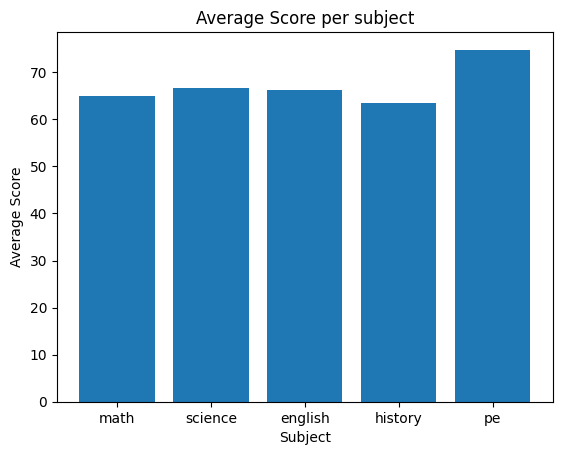

In [19]:
avg_score = df[subject_cols].mean()
plt.Figure()
plt.bar(subject_cols, avg_score )
plt.title("Average Score per subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

*Requirement 2* Histogram

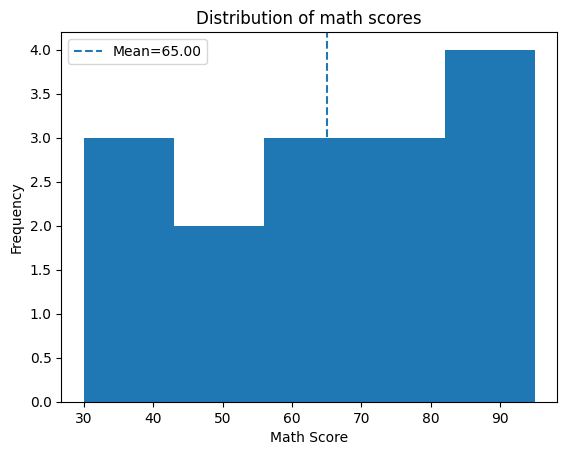

In [20]:
plt.Figure()
plt.hist(df["math"], bins=5)

mean_math = df["math"].mean()
plt.axvline(mean_math,linestyle= "dashed", label = f"Mean={mean_math:.2f}")
plt.title("Distribution of math scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

*Requirement 3* Scatter Plot

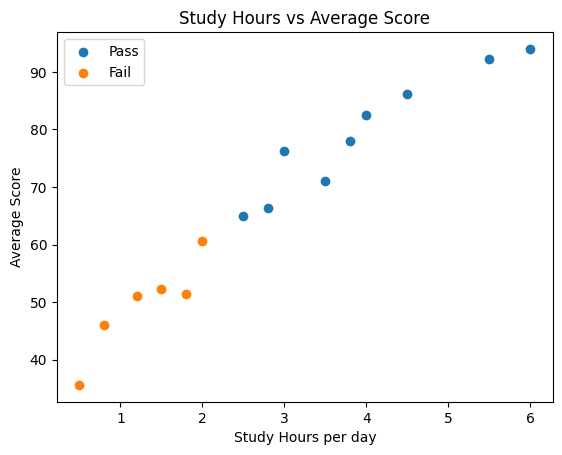

In [21]:
plt.Figure()

pass_df = df[df["passed"]==1]
fail_df = df[df["passed"]==0]

plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

*Requirement 4* Box Plot

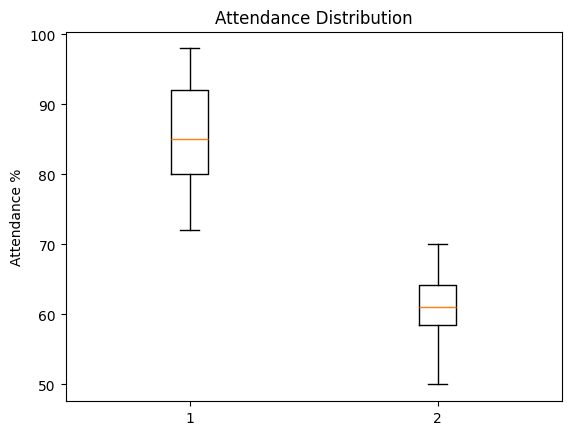

In [22]:
fail_attendance = fail_df["attendance_pct"]
pass_attendance = pass_df["attendance_pct"]

plt.Figure()
plt.boxplot([pass_attendance, fail_attendance], label = ["Pass", "Fail"])
plt.title("Attendance Distribution")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

*Requirement 5* Line Plot

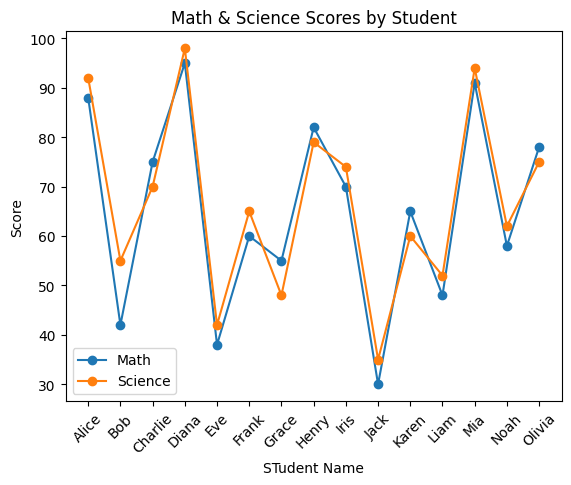

In [23]:
plt.Figure()

plt.plot(df["name"], df["math"], marker = "o", label="Math")
plt.plot(df["name"], df["science"], marker = "o", label="Science")

plt.xticks(rotation=45)
plt.title("Math & Science Scores by Student")
plt.xlabel("STudent Name")
plt.ylabel("Score")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

In [ ]:
!pip install seaborn # Do this if seaborn not installed

***FOR TASK 3***

In [24]:
import seaborn as sns

*Requirement 1 & 3 & 4* Seaborn bar plot

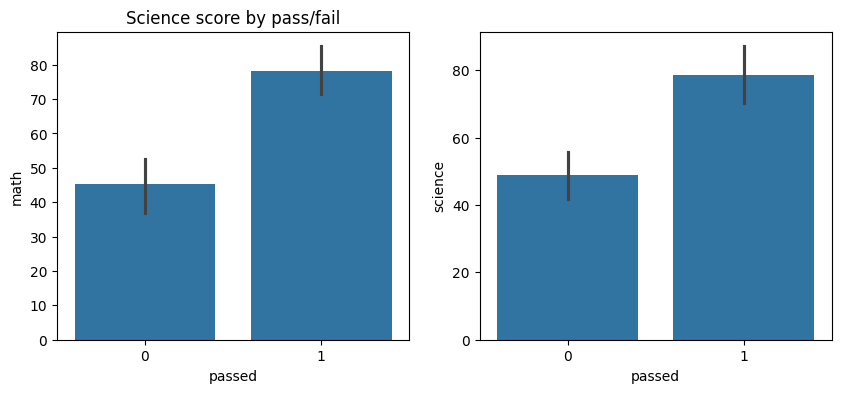

In [ ]:
fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(10,4))

sns.barplot(data= df, x= "passed", y = "math", ax = ax1)
ax1.set_title("Math score by pass/fail")

sns.barplot(data= df, x= "passed", y = "science", ax = ax2)
ax1.set_title("Science score by pass/fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Comment 1: Seaborn need lesser code and is automated Whereas matplotlib need more code and  manual instrution to do same work 
# Comment 2: With Matplotlib you can fully control the type of visual to fine tune according to your need whereas it is not possible with seaborn
# Comment 3:  Matplotlib requires you to preprocess the data before plotting wheras seaborn can gandle raw dataframe

*Requirement 2 & 3* Seaborn scatter plot 

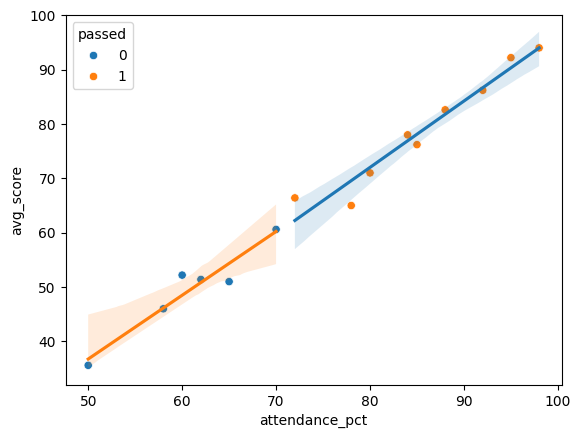

In [26]:
plt.figure()

sns.scatterplot(data = df, x = "attendance_pct", y = "avg_score", hue= "passed")

sns.regplot(data=df[df["passed"]==1], x = "attendance_pct", y = "avg_score", scatter=False, label= "Pass")
sns.regplot(data=df[df["passed"]==0], x = "attendance_pct", y = "avg_score", scatter=False, label= "Fail")

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

***FOR TASK 4***

!pip install scikit-learn # Do this if scikit-learn not installed

*Step 1 & 2*

In [27]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Feature & Target
x = df[["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]] 
y = df["passed"] 

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Model
model = LogisticRegression()
model.fit(X_train_scaled,y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


*Step 3*

In [28]:
# Predict
y_pred = model.predict(X_test_scaled)

# test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

for i , pred in zip(X_test.index, y_pred):
    name = df.loc[i , 'name']
    actual = df.loc[i , 'passed']
    result = "✅" if pred == actual else "❌"
    print(f"{name}: Actual = {actual}, Predicted = {pred} {result}")

Test Accuracy: 1.0
Jack: Actual = 0, Predicted = 0 ✅
Liam: Actual = 0, Predicted = 0 ✅
Alice: Actual = 1, Predicted = 1 ✅


*Step 4*

In [29]:
import numpy as np

english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


Text(0, 0.5, 'Feature')

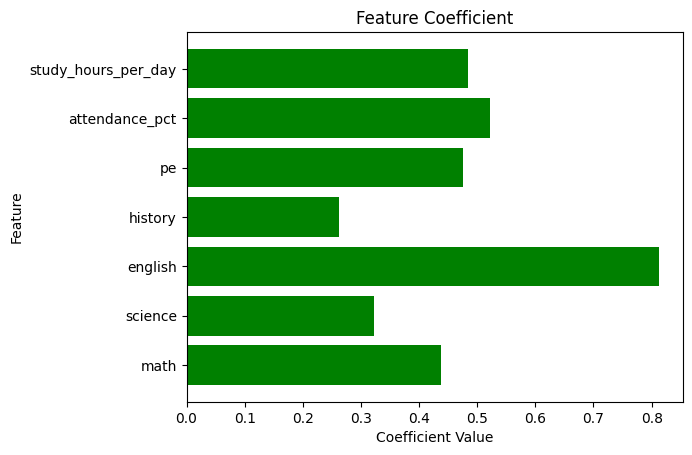

In [33]:
coeffs = model.coef_[0]
features = x.columns

# sorted by absolute value 
sorted_i = np.argsort(np.abs(coeffs))[::-1]

for i in sorted_i:
    print(f"{features[i]}: {coeffs[i]:.4f}")

# horizontal bar chart using Matplotlib
plt.figure()

colors = ["green" if c > 0 else "red" for c in coeffs]

plt.barh(features, coeffs ,color = colors)
plt.title("Feature Coefficient")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

*Step 5*

In [37]:
cols = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]

new_student_df = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=cols ) # order must match feature columns

new_scaled = scaler.transform(new_student_df)

prediction = model.predict(new_scaled)[0]
probablity = model.predict_proba(new_scaled)[0]

print("Prediction:", 'Pass' if prediction == 1 else 'Fail')
print(f"Probability: {probablity}")

Prediction: Pass
Probability: [0.09203526 0.90796474]
